#Importing Required Libraries

In [1]:
import seaborn as sns
import pandas as pd

#Loading the Dataset

In [2]:
titanic = sns.load_dataset('titanic')

#Describing the Dataset

In [3]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [5]:
titanic.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
titanic.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


#Data Cleaning

In [7]:
titanic_clean = titanic.dropna(subset=['age'])

In [8]:
#Mean and median age by gender and survival
group_stats = titanic_clean.groupby(['sex', 'survived'])['age'].describe()
group_stats

count       mean        std   min    25%   50%    75%   max
sex    survived                                                             
female 0          64.0  25.046875  13.618591  2.00  16.75  24.5  33.25  57.0
       1         197.0  28.847716  14.175073  0.75  19.00  28.0  38.00  63.0
male   0         360.0  31.618056  14.056019  1.00  21.75  29.0  39.25  74.0
       1          93.0  27.276022  16.504803  0.42  18.00  28.0  36.00  80.0

#Box Plot: Age Distribution by Gender and Survival Status

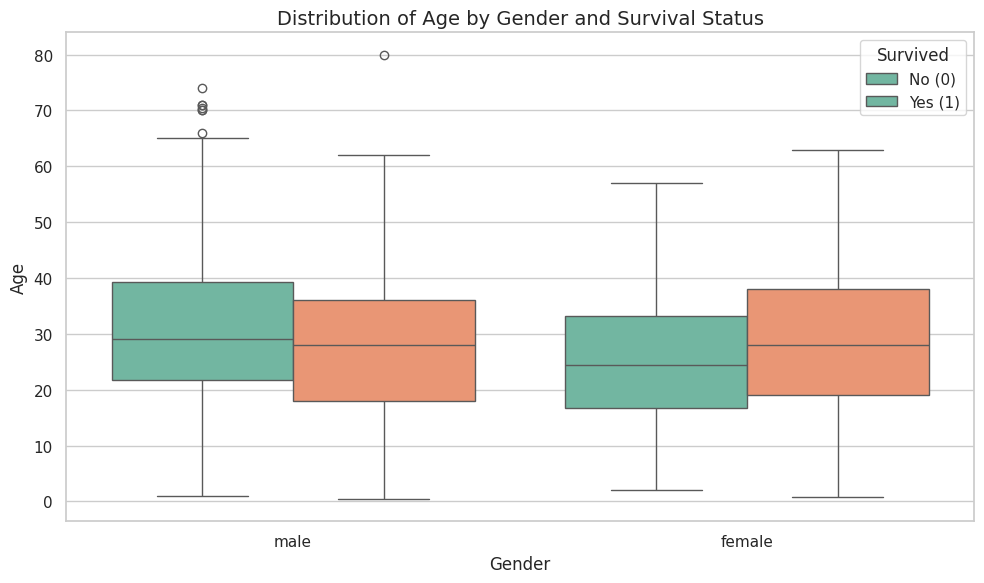

In [9]:
import matplotlib.pyplot as plt

# Set visual style
sns.set(style="whitegrid")

# Box plot
plt.figure(figsize=(10, 6))
sns.boxplot(data=titanic_clean, x='sex', y='age', hue='survived', palette='Set2')

plt.title('Distribution of Age by Gender and Survival Status', fontsize=14)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Age', fontsize=12)
plt.legend(title='Survived', labels=['No (0)', 'Yes (1)'])
plt.tight_layout()
plt.show()


# Violin Plot for Better Density Representation

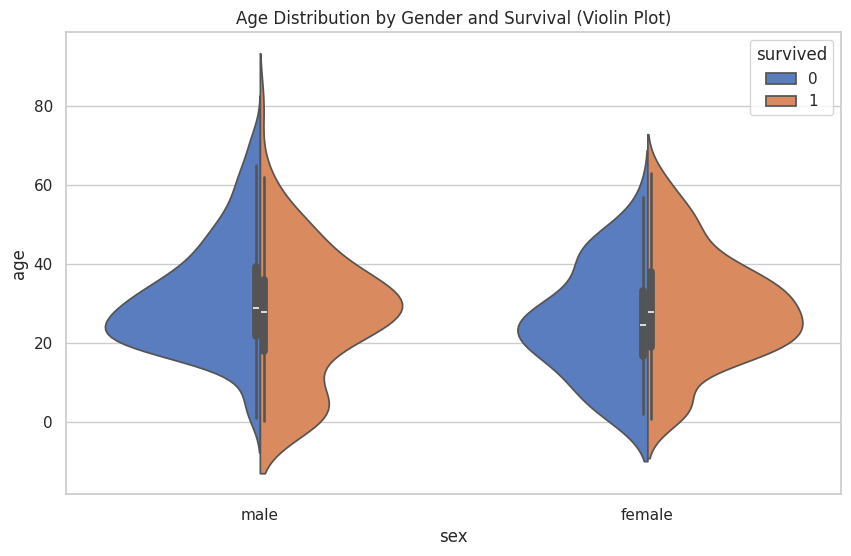

In [10]:
plt.figure(figsize=(10, 6))
sns.violinplot(data=titanic_clean, x='sex', y='age', hue='survived', split=True, palette='muted')
plt.title('Age Distribution by Gender and Survival (Violin Plot)')
plt.show()

#Swarm Plot to See Individual Data Points

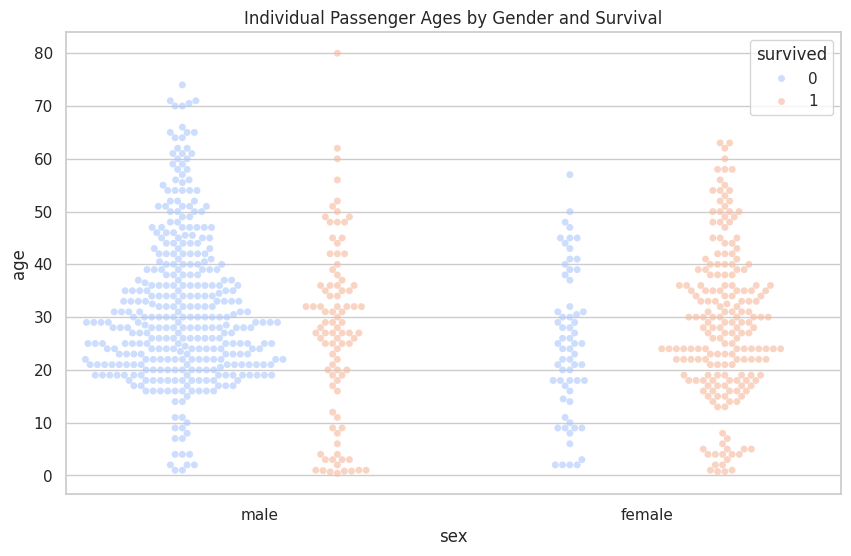

In [11]:
plt.figure(figsize=(10, 6))
sns.swarmplot(data=titanic_clean, x='sex', y='age', hue='survived', palette='coolwarm', dodge=True, alpha=0.6)
plt.title('Individual Passenger Ages by Gender and Survival')
plt.show()